# Day 15: Speculative Decoding — Draft-Target, Medusa, EAGLE
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 5.2

**Prerequisite:** Day 14 (quantization algorithms)

**Goal:** Understand how speculative decoding breaks the memory-bandwidth bottleneck of autoregressive decoding by generating multiple tokens per step.

## What problem does this solve?

Autoregressive decoding is inherently sequential: generate token 1, then token 2, then token 3... Each step requires loading the full model weights from memory. Even if the GPU is underutilized, you can't skip steps.

But what if you could predict several tokens ahead and verify them all in one forward pass? That's speculative decoding: use a small, fast "draft" model to propose candidate tokens, then verify them all with one pass through the large "target" model.

The verification pass can accept multiple tokens at once — if the draft was right, you get N tokens for the price of 1 forward pass. The GPU's parallel compute is finally used efficiently during decode.

## Concept Overview

**Draft-Target Speculative Decoding:**
1. Draft model (small, fast) generates K candidate tokens
2. Target model (large, authoritative) verifies all K tokens in one forward pass
3. Accept tokens up to the first disagreement, reject the rest
4. Generate a replacement token for the first rejected position

**Acceptance criterion:** Token k is accepted if:
$$\text{accept if } U < \frac{p_{target}(x_k | context)}{p_{draft}(x_k | context)}$$

Where U is uniform random. This preserves the target model's distribution exactly.

**Medusa:** Multiple draft heads attached to the same model. Instead of a separate draft model, Medusa adds N parallel prediction heads that each predict tokens N steps ahead.

**EAGLE / EAGLE-2 / EAGLE-3:** Uses feature-level (not token-level) draft — drafts from the model's hidden states rather than token probabilities, achieving higher acceptance rates. EAGLE-2 adds tree-based draft expansion; EAGLE-3 drafts from multiple target layers simultaneously.

**N-gram (prompt lookup):** No draft model at all. Match the last N tokens of the running output against earlier positions in the sequence and propose the tokens that followed. Free on RAG/code workloads where outputs echo the input.

**Production note:** vLLM V1 supports n-gram and EAGLE only. Draft-target, Medusa, and MLP speculator are V0-only.

**Infrastructure analogy:** Like speculative execution in CPUs. The CPU predicts the outcome of a branch and executes ahead — if wrong, discard and redo. If right, free speedup.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


In [3]:
# Simulate speculative decoding with rejection sampling

import torch
import torch.nn.functional as F

def speculative_decode_step(target_probs, draft_probs, draft_tokens, n_draft=4):
    """
    Simulate one speculative decoding step.

    target_probs: (n_draft, vocab) - target model probabilities for each position
    draft_probs:  (n_draft, vocab) - draft model probabilities
    draft_tokens: (n_draft,) - tokens proposed by draft model

    Returns: accepted_tokens, rejection_point
    """
    accepted = []

    for i in range(n_draft):
        t = draft_tokens[i].item()
        # Acceptance probability: min(1, p_target(t) / p_draft(t))
        p_target = target_probs[i, t].item()
        p_draft = draft_probs[i, t].item()

        accept_prob = min(1.0, p_target / (p_draft + 1e-10))

        if torch.rand(1).item() < accept_prob:
            accepted.append(t)
        else:
            # Rejection: sample replacement from adjusted distribution
            adjusted = F.relu(target_probs[i] - draft_probs[i])
            if adjusted.sum() > 0:
                adjusted = adjusted / adjusted.sum()
                replacement = torch.multinomial(adjusted, 1).item()
            else:
                replacement = torch.multinomial(target_probs[i], 1).item()
            accepted.append(replacement)
            return accepted, i  # rejected at position i

    # All accepted! Also get bonus token from target at position n_draft+1
    return accepted, n_draft

# Simulate token generation with different draft quality levels
torch.manual_seed(42)
vocab_size = 1000
n_draft = 4
n_simulation_steps = 1000

# Simulate different draft model qualities
draft_qualities = {
    "Perfect draft (100% match)": 1.0,
    "Good draft (80% match)": 0.8,
    "Medium draft (60% match)": 0.6,
    "Poor draft (40% match)": 0.4,
    "Random draft (0% match)": 0.0,
}

print("Speculative decoding: tokens generated per step")
print(f"  Spec decode step = {n_draft} draft tokens proposed")
print()
print(f"{'Draft quality':<35} {'Avg tokens/step':>16} {'Speedup vs autoregressive':>26}")
print("-" * 80)

for quality_name, match_rate in draft_qualities.items():
    total_tokens = 0

    for _ in range(n_simulation_steps):
        # Sample target distribution
        target_logits = torch.randn(n_draft, vocab_size)
        target_probs = F.softmax(target_logits, dim=-1)

        # Draft distribution: mix of correct and random
        if match_rate > 0:
            # mix target probs with noise based on match_rate
            noise = F.softmax(torch.randn(n_draft, vocab_size), dim=-1)
            draft_probs = match_rate * target_probs + (1 - match_rate) * noise
            draft_probs = draft_probs / draft_probs.sum(dim=-1, keepdim=True)
        else:
            draft_probs = F.softmax(torch.randn(n_draft, vocab_size), dim=-1)

        # Sample draft tokens
        draft_tokens = torch.multinomial(draft_probs, 1).squeeze(-1)

        accepted, _ = speculative_decode_step(target_probs, draft_probs, draft_tokens, n_draft)
        total_tokens += len(accepted)

    avg_tokens = total_tokens / n_simulation_steps
    speedup = avg_tokens  # 1 autoregressive step = 1 token; spec step = avg_tokens tokens
    print(f"{quality_name:<35} {avg_tokens:>16.2f} {speedup:>24.2f}x")

print()
print("Key insight: even with 60% match rate, speculative decoding delivers ~2x speedup.")
print("The target model's distribution is preserved exactly regardless of draft quality.")

Speculative decoding: tokens generated per step
  Spec decode step = 4 draft tokens proposed

Draft quality                        Avg tokens/step  Speedup vs autoregressive
--------------------------------------------------------------------------------
Perfect draft (100% match)                      4.00                     4.00x
Good draft (80% match)                          3.42                     3.42x
Medium draft (60% match)                        2.88                     2.88x
Poor draft (40% match)                          2.54                     2.54x
Random draft (0% match)                         1.78                     1.78x

Key insight: even with 60% match rate, speculative decoding delivers ~2x speedup.
The target model's distribution is preserved exactly regardless of draft quality.


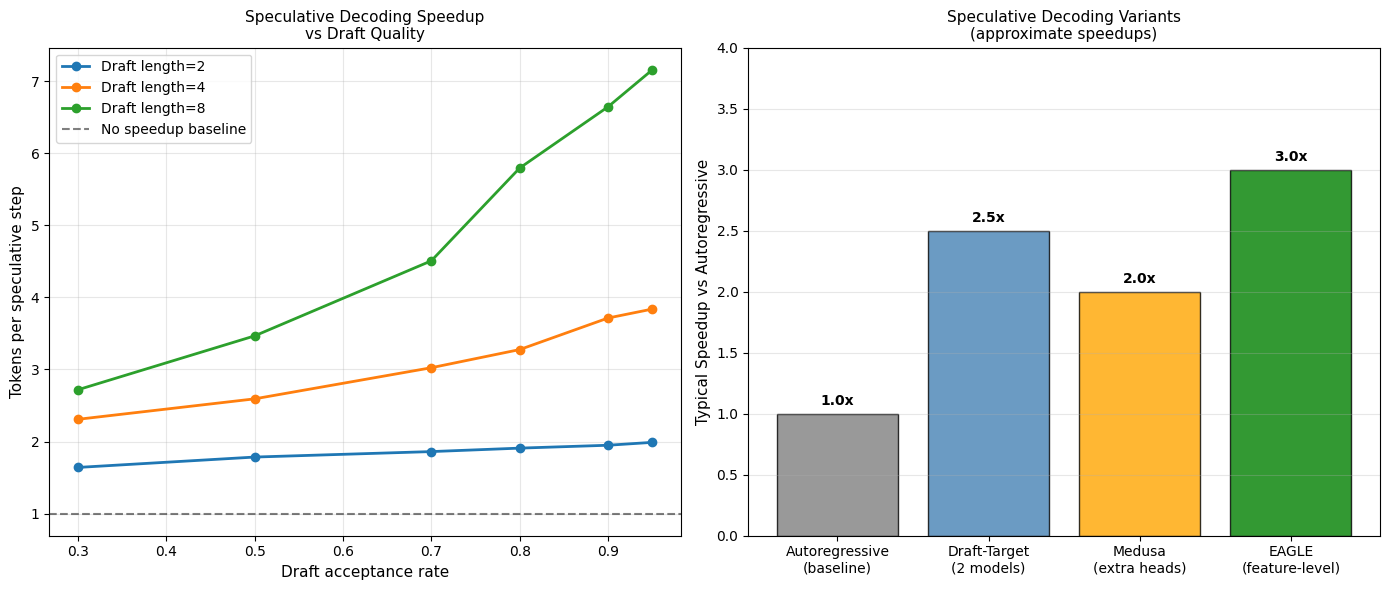

In [4]:
# Visualize acceptance rate by draft quality and number of draft tokens

import numpy as np

def simulate_acceptance_rate(match_rate, n_draft, n_samples=5000, vocab_size=1000):
    """Estimate average tokens per step for given match rate."""
    total_tokens = 0
    for _ in range(n_samples):
        target_probs = F.softmax(torch.randn(n_draft, vocab_size), dim=-1)
        if match_rate > 0:
            noise = F.softmax(torch.randn(n_draft, vocab_size), dim=-1)
            draft_probs = match_rate * target_probs + (1 - match_rate) * noise
        else:
            draft_probs = F.softmax(torch.randn(n_draft, vocab_size), dim=-1)
        draft_probs = draft_probs / draft_probs.sum(dim=-1, keepdim=True)
        draft_tokens = torch.multinomial(draft_probs, 1).squeeze(-1)
        accepted, _ = speculative_decode_step(target_probs, draft_probs, draft_tokens, n_draft)
        total_tokens += len(accepted)
    return total_tokens / n_samples

match_rates = [0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
draft_lengths = [1, 2, 4, 8, 16]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: speedup vs match rate for different draft lengths
for n_d in [2, 4, 8]:
    speedups = [simulate_acceptance_rate(mr, n_d, n_samples=500) for mr in match_rates]
    ax1.plot(match_rates, speedups, 'o-', linewidth=2, label=f'Draft length={n_d}')

ax1.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='No speedup baseline')
ax1.set_xlabel('Draft acceptance rate', fontsize=11)
ax1.set_ylabel('Tokens per speculative step', fontsize=11)
ax1.set_title('Speculative Decoding Speedup\nvs Draft Quality', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Illustration of speculation variants
variants = ['Autoregressive\n(baseline)', 'Draft-Target\n(2 models)', 'Medusa\n(extra heads)', 'EAGLE\n(feature-level)']
speedups_v = [1.0, 2.5, 2.0, 3.0]
colors_v = ['gray', 'steelblue', 'orange', 'green']
bars = ax2.bar(variants, speedups_v, color=colors_v, alpha=0.8, edgecolor='black')
for bar, sp in zip(bars, speedups_v):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{sp}x', ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel('Typical Speedup vs Autoregressive', fontsize=11)
ax2.set_title('Speculative Decoding Variants\n(approximate speedups)', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_ylim(0, 4)

plt.tight_layout()
plt.show()

## N-gram Speculation: Draft Without a Model

Draft-Target, Medusa, and EAGLE all need a neural network to propose tokens. N-gram speculation skips that entirely — the "draft" is a lookup in the existing sequence.

**How it works:** take the last N tokens of the running output (e.g., last 3). Search backwards through the prompt + prior output for that same N-gram. Where it matches, the K tokens that followed it become the proposal. Verify with the target model as usual.

**Why it works in practice:**
- RAG: answers often quote verbatim from retrieved context
- Code completion: repeated identifiers and boilerplate
- Long-context chat: the model echoes phrases from the prompt

Zero parameters. No training. No draft forward passes. vLLM exposes this as `speculative_config={"method": "ngram", "prompt_lookup_max": 3}`. Real-world speedups: 20-30% on repetitive workloads, ~0% on fully novel generation.

In [5]:
# N-gram speculation: propose continuations from the existing sequence itself
import random
random.seed(0)

def ngram_propose(sequence, n=3, k=4):
    """
    Take the last n tokens, look backwards for a matching n-gram, return
    the k tokens that followed it as the proposal.
    """
    if len(sequence) < n + 1:
        return []
    ngram = tuple(sequence[-n:])
    for i in range(len(sequence) - n - 1, -1, -1):
        if tuple(sequence[i:i+n]) == ngram:
            return sequence[i+n:i+n+k]
    return []

# Example 1: RAG-style sequence where output echoes the prompt
rag_prompt = [1, 2, 3, 4, 5, 10, 20, 30, 40, 50, 60, 70]
rag_output = [99, 5, 10, 20]  # last 3 tokens (5, 10, 20) appear earlier
seq = rag_prompt + rag_output
print(f"RAG-style workload:")
print(f"  Last 3 tokens:        {seq[-3:]}")
print(f"  Proposed continuation: {ngram_propose(seq, n=3, k=4)}")
print()

# Example 2: novel/creative sequence with no repeats
creative = list(range(500, 600))
print(f"Creative workload (no repeats):")
print(f"  Proposed continuation: {ngram_propose(creative, n=3, k=4)}")
print()

# Benchmark: simulate end-to-end speedup across workload types
def simulate_ngram_speedup(sequence, n=3, k=4):
    """
    Walk through the sequence, propose an n-gram continuation at each position,
    verify against the ground-truth next tokens, and count target forward passes.
    Returns average tokens produced per target-model call.
    """
    target_calls = 0
    tokens_out = 0
    i = n + 1
    while i < len(sequence):
        proposals = ngram_propose(sequence[:i], n=n, k=k)
        if not proposals:
            # No match — fall back to plain autoregressive step
            target_calls += 1
            tokens_out += 1
            i += 1
            continue
        # Verify: longest prefix of proposals that equals the actual continuation
        actual = sequence[i:i+len(proposals)]
        accepted = 0
        for pred, truth in zip(proposals, actual):
            if pred == truth:
                accepted += 1
            else:
                break
        target_calls += 1
        tokens_out += accepted + 1  # accepted tokens + 1 corrected token from target
        i += accepted + 1
    return tokens_out / max(target_calls, 1)

# Build representative workloads
random.seed(1)
phrases = [[1,2,3,4,5], [10,20,30,40], [100,101,102,103], [7,8,9]]
rag_like = []
for _ in range(80):
    if random.random() < 0.6:
        rag_like.extend(random.choice(phrases))
    else:
        rag_like.append(random.randint(500, 1000))
creative_like = [random.randint(500, 2000) for _ in range(300)]

print(f"{'Workload':30s} {'Tokens/target-call':>20s}")
print("-" * 52)
for name, s in [("RAG-like (60% repeated phrases)", rag_like),
                ("Creative (all novel tokens)", creative_like)]:
    speedup = simulate_ngram_speedup(s, n=3, k=4)
    print(f"{name:30s} {speedup:>18.2f}x")

RAG-style workload:
  Last 3 tokens:        [5, 10, 20]
  Proposed continuation: [30, 40, 50, 60]

Creative workload (no repeats):
  Proposed continuation: []

Workload                         Tokens/target-call
----------------------------------------------------
RAG-like (60% repeated phrases)               1.53x
Creative (all novel tokens)                  1.00x


## Try These Experiments

1. **Token acceptance probability derivation:** Prove mathematically that the speculative decoding acceptance criterion preserves the target distribution. Show that the expected token distribution after rejection sampling equals the target distribution.

2. **Medusa head training cost:** Medusa adds K extra linear heads to predict tokens K steps ahead. If the model has hidden_dim=4096 and vocab_size=32000, what is the parameter overhead for 3 Medusa heads? What fraction of the original model size is this?

3. **Draft model size sweep:** Speculative decoding speedup depends on the draft model being fast enough. If the target model takes 50ms per step and the draft model takes X ms per step, what is the maximum draft overhead X that still gives a net speedup with 75% acceptance rate and N=4 draft tokens?

## Key Takeaways

- Speculative decoding breaks the sequential bottleneck by proposing tokens that the target model verifies in parallel.
- The acceptance criterion (rejection sampling) guarantees the output distribution exactly matches the target model — no quality loss.
- Draft quality matters but even 60% acceptance gives ~2x speedup. Getting draft quality right is more important than extending draft length past 4-8 tokens.
- Medusa and EAGLE remove the separate draft model. EAGLE-2 (tree-based draft) and EAGLE-3 (multi-layer feature draft) push acceptance 10-15% higher.
- N-gram speculation needs no model at all — 20-30% speedup on RAG/code, zero overhead when matches fail.
- vLLM V1 only ships n-gram and EAGLE today; draft-target, Medusa, and MLP speculator remain V0-only.
- **What's next:** Day 16 — KV Cache: prefix caching and cache-aware routing.

## References
- *Inference Engineering* Ch 5.2 — Philip Kiely (Baseten Books, 2026)
- "Faster LLMs: Accelerate Inference with Speculative Decoding" — Isaac Ke, IBM Technology (2025): https://www.youtube.com/watch?v=VkWlLSTdHs8
- Leviathan et al. (2022) — "Fast Inference from Transformers via Speculative Decoding"
- Cai et al. (2023) — "Medusa: Simple LLM Inference Acceleration Framework with Multiple Decoding Heads"
- Li et al. (2024–2025) — "EAGLE: Speculative Sampling Requires Rethinking Feature Uncertainty"
- vLLM docs: https://docs.vllm.ai/en/latest/features/speculative_decoding/